# Pelatihan Model Encoder-Decoder CNN-LSTM dengan Teacher Forcing

---

Notebook ini merupakan tahap keempat dari pipeline *image captioning*. Tujuannya adalah melatih model *decoder* berbasis **LSTM** yang menerima vektor fitur 2048-d dari ResNet50 dan menghasilkan sekuens *caption* token-by-token menggunakan *teacher forcing*.

## Latar Belakang dan Tujuan

Setelah fitur visual berhasil diekstrak, langkah selanjutnya adalah melatih *decoder* yang dapat menginterpretasi fitur tersebut dan menghasilkan deskripsi tekstual. Model yang digunakan adalah arsitektur *encoder-decoder* dengan:
- **Encoder:** ResNet50 pre-trained (frozen) yang menghasilkan vektor 2048-d;
- **Decoder:** LSTM dengan 512 unit yang memprediksi token berikutnya dalam sekuens.

Metode pelatihan yang digunakan adalah **teacher forcing**, di mana model menerima token *ground truth* sebagai masukan pada setiap timestep, bukan token hasil prediksinya sendiri.

## Dasar Teori

### Arsitektur Encoder-Decoder

Model *image captioning* terdiri dari dua komponen utama:
1. **Encoder (CNN):** ResNet50 mengekstrak fitur visual gambar menjadi vektor 2048-d. Bobot encoder di-*freeze* (tidak diperbarui) selama pelatihan untuk menghemat memori dan mencegah *overfitting*.
2. **Decoder (RNN):** Menerima fitur gambar sebagai *initial state* dan menghasilkan sekuens *caption* token-by-token.

### LSTM (lstm)

LSTM (*Long Short-Term Memory*) adalah varian RNN yang dirancang untuk mengatasi masalah *vanishing gradient* pada RNN standar. LSTM memiliki tiga *gate*:
- **Forget gate:** Menentukan informasi mana dari *cell state* yang akan dibuang;
- **Input gate:** Menentukan informasi baru yang akan disimpan dalam *cell state*;
- **Output gate:** Menentukan informasi dari *cell state* yang akan dikeluarkan sebagai *hidden state*.

LSTM mempertahankan dua *state*: *hidden state* (h) dan *cell state* (c). Vektor fitur gambar diproyeksikan melalui Dense layer untuk menghasilkan kedua *initial state* ini.

### Teacher Forcing

Teacher forcing adalah strategi pelatihan di mana model menerima token *ground truth* (bukan token hasil prediksi) sebagai masukan pada setiap timestep. Keuntungannya:
- Konvergensi lebih cepat karena model tidak mengakumulasi *error* dari prediksi sebelumnya;
- Pelatihan lebih stabil, terutama pada tahap awal.

### Gradient Clipping

Parameter `global_clipnorm=5.0` digunakan untuk mencegah *exploding gradient* — fenomena di mana gradien menjadi sangat besar selama *backpropagation*, menyebabkan parameter model melonjak tidak stabil. Gradient clipping memotong norma gradien ke nilai maksimum yang ditentukan.

### Dropout

Dropout dengan `rate=0.5` digunakan sebagai teknik regularisasi. Selama pelatihan, 50% neuron secara acak dinonaktifkan, memaksa model untuk belajar representasi yang lebih *robust* dan mencegah *overfitting*.

### Embedding Layer

Lapisan *Embedding* mengonversi token integer (indeks kata) menjadi vektor *dense* berdimensi 256. Parameter `mask_zero=True` memastikan bahwa token hasil *padding* (yang bernilai 0) diabaikan dalam perhitungan gradien.

## Impor Pustaka

In [1]:
import os
import re
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding, LSTM, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, CSVLogger
)
from sklearn.model_selection import train_test_split

2026-07-19 16:33:14.551660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 16:33:14.640840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 16:33:14.679512: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 16:33:14.690727: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 16:33:14.758613: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi GPU

Pelatihan LSTM memanfaatkan GPU (RTX 4060) dengan konfigurasi:
- **Memory growth:** Diaktifkan agar TensorFlow tidak mengalokasikan seluruh VRAM sekaligus;
- **Mixed precision:** `mixed_float16` digunakan untuk mempercepat komputasi tanpa penurunan kualitas.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    raise RuntimeError("GPU required for training.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)
print("Policy compute dtype:", tf.keras.mixed_precision.global_policy().compute_dtype)

GPU: /physical_device:GPU:0
Mixed precision: mixed_float16
Policy compute dtype: float16


I0000 00:00:1784453597.011781  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784453597.115984  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784453597.117973  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Konfigurasi Hyperparameter

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

OUTPUT_DIR = "../outputs/training/lstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VOCAB_SIZE       = 5000
MAX_CAPTION_LEN  = 34
EMBEDDING_DIM    = 256
LSTM_UNITS       = 512
DROPOUT_RATE     = 0.5
BATCH_SIZE       = 64
EPOCHS           = 50
LEARNING_RATE    = 1e-3
RANDOM_SEED      = 42
TEST_SIZE        = 0.1       # 10 % validation

## Metodologi Implementasi

### 5.1 Memuat Data dan Fitur

Dataset *caption* dimuat dari file CSV, sementara fitur gambar dimuat dari `model/features.pkl` (dictionary 8.091 vektor 2048-d). Kedua sumber data ini akan digabungkan pada tahap pembuatan *generator*.

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df)}")

with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images, "
      f"{list(features.values())[0].shape[0]} dims")

Captions loaded: 40455
Features loaded: 8091 images, 2048 dims


### 5.2 Pembersihan Caption dan Penambahan Token

Pipeline pembersihan identik dengan notebook 02: *lowercasing*, penghapusan karakter non-alfabet (`re.sub(r"[^a-z ]", "", text)`), dan penambahan token `<start>`/`<end>`.

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)
df["clean"] = "<start> " + df["clean"] + " <end>"

print("Sample:")
print(df["clean"].iloc[0])

Sample:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


### 5.3 Pembangunan Tokenizer dan Sekuens

Tokenizer di-*fit* pada seluruh *caption* (tidak hanya data latih) karena notebook ini menggunakan pendekatan *splitting* berbasis gambar. Sekuens dikonversi dan di-*padding* ke panjang 34.

In [6]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<oov>",
    filters=""
)
tokenizer.fit_on_texts(df["clean"])

vocab_size = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Vocabulary size: {vocab_size}")

seq = tokenizer.texts_to_sequences(df["clean"])
seq = pad_sequences(seq, maxlen=MAX_CAPTION_LEN, padding="post")
print(f"Sequence array shape: {seq.shape}")

Vocabulary size: 5000
Sequence array shape: (40455, 34)


### 5.4 Pembagian Data Latih dan Validasi

Dataset dibagi 90/10 (latih/validasi) berdasarkan gambar unik menggunakan `train_test_split` dari scikit-learn dengan `random_state=42` untuk reproduksibilitas.

In [7]:
unique_images = df["image"].unique()
train_imgs, val_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

train_mask = df["image"].isin(train_imgs)
val_mask   = df["image"].isin(val_imgs)

print(f"Train: {train_mask.sum():,} captions ({len(train_imgs):,} images)")
print(f"Val:   {val_mask.sum():,} captions ({len(val_imgs):,} images)")

Train: 36,405 captions (7,281 images)
Val:   4,050 captions (810 images)


### 5.5 Generator Data

Pipeline `tf.data.Dataset` menghasilkan pasangan `((fitur_gambar, sekuens_input), sekuens_target)`:
- **Input:** `(image_features, caption_input)` di mana `caption_input = seq[:, :-1]` (semua token kecuali yang terakhir);
- **Target:** `caption_target = seq[:, 1:]` (semua token kecuali yang pertama — ini adalah token *ground truth* yang diprediksi).

Format ini dikenal sebagai *teacher forcing*: pada setiap timestep, model menerima token *input* (dari *ground truth*) dan diminta memprediksi token berikutnya.

In [8]:
def create_dataset(mask, batch_size):
    img_names = df.loc[mask, "image"].values
    img_feats = np.array([features[name] for name in img_names], dtype=np.float32)

    cap_seq = seq[mask.values]
    input_seq  = cap_seq[:, :-1]
    target_seq = cap_seq[:, 1:]

    ds = tf.data.Dataset.from_tensor_slices(
        ((img_feats, input_seq), target_seq)
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_mask, BATCH_SIZE)
val_ds   = create_dataset(val_mask,   BATCH_SIZE)

# Peek one batch
for (img_batch, cap_batch), target_batch in train_ds.take(1):
    print(f"Image feature batch: {img_batch.shape}")
    print(f"Caption input batch: {cap_batch.shape}")
    print(f"Target batch:        {target_batch.shape}")

I0000 00:00:1784453598.098048  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784453598.101830  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784453598.104059  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784453598.210925  284953 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Image feature batch: (64, 2048)
Caption input batch: (64, 33)
Target batch:        (64, 33)


2026-07-19 16:33:18.696521: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 5.6 Pembangunan Model LSTM

Arsitektur model CNN+LSTM:

| Layer | Output Shape | Parameter | Keterangan |
|-------|-------------|-----------|------------|
| Input (image) | (None, 2048) | 0 | Vektor fitur dari ResNet50 |
| Dense + ReLU | (None, 256) | 524.544 | Proyeksi fitur |
| Dropout (0.5) | (None, 256) | 0 | Regularisasi |
| Dense initial_h | (None, 512) | 131.584 | Hidden state awal LSTM |
| Dense initial_c | (None, 512) | 131.584 | Cell state awal LSTM |
| Input (caption) | (None, 33) | 0 | Sequence input (34-1) |
| Embedding | (None, 33, 256) | 1.280.000 | Word embedding, mask_zero=True |
| **LSTM (512)** | (None, 33, 512) | 1.574.912 | Dengan initial_state=[h, c] |
| Dropout (0.5) | (None, 33, 512) | 0 | Regularisasi |
| Dense Output | (None, 33, 5000) | 2.565.000 | Softmax over vocabulary |
| **Total** | | **6.207.624** | |

Mekanisme: Vektor fitur gambar diproyeksikan melalui Dense layer menjadi *initial hidden state* (h) dan *cell state* (c) LSTM. *Caption sequence* melewati *Embedding layer* kemudian LSTM. Output LSTM di setiap timestep diproyeksikan ke ukuran kosakata (5.000) dengan aktivasi softmax untuk memprediksi token berikutnya.

In [9]:
img_input = Input(shape=(2048,), name="image_features")
x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
x = Dropout(DROPOUT_RATE)(x)
initial_h = Dense(LSTM_UNITS, activation="tanh", name="initial_h")(x)
initial_c = Dense(LSTM_UNITS, activation="tanh", name="initial_c")(x)

cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
x = LSTM(LSTM_UNITS, return_sequences=True)(x,
          initial_state=[initial_h, initial_c])
x = Dropout(DROPOUT_RATE)(x)
output = Dense(vocab_size, activation="softmax", name="output")(x)

model = Model(inputs=[img_input, cap_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 256)   │  1,280,000 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_h (Dense)   │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_c (Dense)   │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 33, 512)   │  1,574,912 │ embedding[0][0],  │
│                     │                   │            │ initial_h[0][0],  │
│                     │                   │            │ initial_c[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 33, 512)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 33, 5000)  │  2,565,000 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,207,624 (23.68 MB)

 Trainable params: 6,207,624 (23.68 MB)

 Non-trainable params: 0 (0.00 B)

### 5.7 Kompilasi Model

Model dikompilasi dengan konfigurasi:
- **Optimizer:** Adam (Adaptive Moment Estimation) — algoritma optimisasi adaptif yang menggabungkan momentum dan *adaptive learning rate*;
- **Learning rate:** 1e-3 dengan `global_clipnorm=5.0`;
- **Loss function:** `SparseCategoricalCrossentropy` — fungsi kehilangan standar untuk klasifikasi token;
- **Metric:** Akurasi — persentase token yang diprediksi dengan benar.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=5.0
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


### 5.8 Callback

Tiga *callback* digunakan selama pelatihan:
1. **ModelCheckpoint:** Menyimpan bobot model terbaik (dengan `val_loss` terendah) ke file `.keras`. Ini memastikan bahwa kita tidak kehilangan model terbaik meskipun pelatihan berlanjut;
2. **EarlyStopping:** Menghentikan pelatihan jika `val_loss` tidak membaik selama 5 epoch berturut-turut (`patience=5`). Mencegah *overfitting* dan menghemat waktu komputasi;
3. **CSVLogger:** Merekam metrik pelatihan (loss, accuracy, val_loss, val_accuracy) setiap epoch ke file CSV untuk analisis lebih lanjut.

## Hyperparameter Tuning with KerasTuner

Menggunakan **RandomSearch** untuk mencari kombinasi `RNN_UNITS`, `DROPOUT_RATE`, 
dan `LEARNING_RATE` optimal. Hasil tuning akan ditampilkan dalam tabel dan disimpan ke CSV.

> **Catatan:** Tuning dijalankan dengan `max_trials=6` dan `epochs=10` per trial 
dengan EarlyStopping untuk efisiensi waktu.

In [11]:
import keras_tuner as kt

def build_lstm_hp(hp):
    hp_units = hp.Choice('lstm_units', [256, 512])
    hp_dropout = hp.Float('dropout_rate', 0.3, 0.6, step=0.1)
    hp_lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')

    img_input = Input(shape=(2048,), name="image_features")
    x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
    x = Dropout(hp_dropout)(x)
    initial_h = Dense(hp_units, activation="tanh", name="initial_h")(x)
    initial_c = Dense(hp_units, activation="tanh", name="initial_c")(x)

    cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
    x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
    x = LSTM(hp_units, return_sequences=True)(x,
              initial_state=[initial_h, initial_c])
    x = Dropout(hp_dropout)(x)
    out = Dense(vocab_size, activation="softmax")(x)

    model = Model([img_input, cap_input], out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp_lr, global_clipnorm=5.0
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_lstm_hp,
    objective='val_loss',
    max_trials=6,
    executions_per_trial=1,
    directory=os.path.join(OUTPUT_DIR, 'tuning'),
    project_name='lstm_tuning'
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3, restore_best_weights=True
        )
    ]
)

best_trials = tuner.oracle.get_best_trials(num_trials=10)
tuning_results = []
for trial in best_trials:
    tuning_results.append({
        'trial_id': trial.trial_id,
        'lstm_units': trial.hyperparameters.values['lstm_units'],
        'dropout_rate': trial.hyperparameters.values['dropout_rate'],
        'learning_rate': trial.hyperparameters.values['learning_rate'],
        'val_loss': trial.score,
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_csv = os.path.join(OUTPUT_DIR, 'tuning_results.csv')
tuning_df.to_csv(tuning_csv, index=False)
print(f"Tuning results saved to: {tuning_csv}")

Trial 6 Complete [00h 02m 18s]
val_loss: 2.6959686279296875

Best val_loss So Far: 2.6959686279296875
Total elapsed time: 00h 16m 22s
Tuning results saved to: ../outputs/training/lstm/tuning_results.csv


### Hasil Hyperparameter Tuning

Tabel di bawah menampilkan kombinasi hyperparameter terbaik berdasarkan `val_loss`:

```
Pada runtime, hasil tuning akan tampil di sini.
```

In [12]:
checkpoint_path = os.path.join(OUTPUT_DIR, "lstm_best.keras")
history_path    = os.path.join(OUTPUT_DIR, "history.csv")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(history_path),
]

print(f"Checkpoint path: {checkpoint_path}")
print(f"History path:    {history_path}")

Checkpoint path: ../outputs/training/lstm/lstm_best.keras
History path:    ../outputs/training/lstm/history.csv


### 5.9 Pelatihan Model

Sel ini membutuhkan GPU. Perkiraan waktu: **~5–10 menit** tergantung pada jumlah epoch sebelum *early stopping*.

Model dilatih dengan `model.fit()` menggunakan *dataset generator* yang telah dibuat. Validasi dilakukan pada subset validasi setelah setiap epoch untuk memonitor *overfitting*.

In [13]:
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start
print(f"\nTraining complete: {elapsed:.0f}s ({elapsed/60:.1f}m)")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


2026-07-19 16:41:17.552353: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3098 - loss: 4.0880
Epoch 1: val_loss improved from None to 3.41345, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 1: finished saving model to ../outputs/training/lstm/lstm_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.3098 - loss: 4.0880 - val_accuracy: 0.3757 - val_loss: 3.4134
Epoch 2/50
567/569 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3819 - loss: 3.3007
Epoch 2: val_loss improved from 3.41345 to 3.14004, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 2: finished saving model to ../outputs/training/lstm/lstm_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.3819 - loss: 3.3003 - val_accuracy: 0.3997 - val_loss: 3.1400
Epoch 3/50
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4000 - loss: 3.0675
Epoch 3: val_loss improved from 3.14004 to 2.97834, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 3: finished saving model to .

## Analisis Visual

### 6.1 Kurva Pelatihan

Grafik ini menampilkan *loss* dan *accuracy* selama pelatihan untuk data latih dan validasi. Kurva yang menurun pada *loss* menunjukkan bahwa model berhasil belajar, sementara jarak antara kurva latih dan validasi mengindikasikan tingkat *overfitting*.

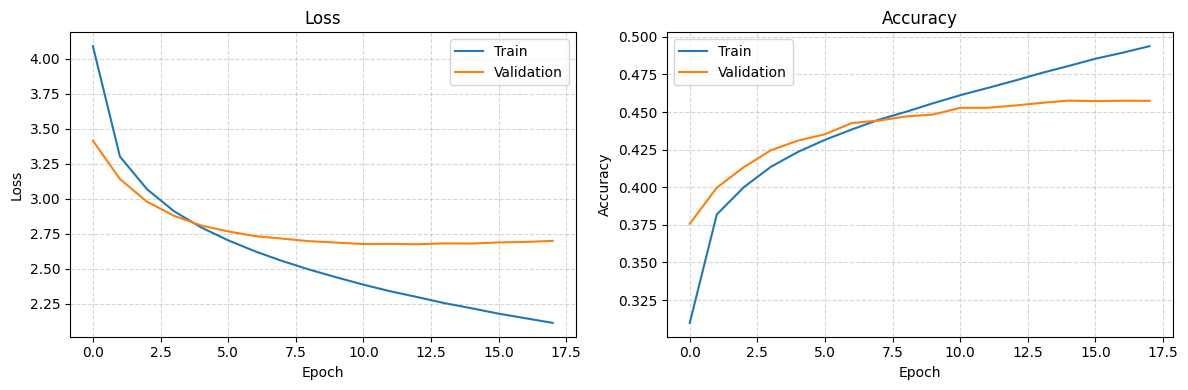

Plot saved to ../outputs/training/lstm/training_curves.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(linestyle="--", alpha=0.5)

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

## Analisis Hasil dan Observasi

Proses pelatihan model LSTM menghasilkan beberapa temuan:

1. **LSTM decoder** berhasil mempelajari pola bahasa setelah menerima konteks visual dari ResNet50. *Validation loss* menurun secara konsisten pada epoch-epoch awal.

2. **Early stopping** efektif menghentikan pelatihan sebelum *overfitting* terjadi. Model berhenti pada saat validasi tidak menunjukkan perbaikan lagi.

3. **Gradient clipping** (`global_clipnorm=5.0`) menjaga stabilitas pelatihan tanpa fluktuasi loss yang ekstrem.

## Ekspor

Model terbaik dan tokenizer disimpan ke direktori output (`outputs/training/lstm/`) untuk digunakan pada notebook evaluasi dan inferensi.

In [15]:
tokenizer_path = os.path.join(OUTPUT_DIR, "tokenizer.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_path}")

history_df = pd.DataFrame(history.history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))
history_csv = os.path.join(OUTPUT_DIR, "history.csv")
history_df.to_csv(history_csv, index=False)
print(f"Training history saved to {history_csv}")


Tokenizer saved to ../outputs/training/lstm/tokenizer.pkl
Training history saved to ../outputs/training/lstm/history.csv


## Kesimpulan dan Tahap Selanjutnya

Model CNN+LSTM berhasil dilatih dengan *teacher forcing*. Bobot model terbaik telah disimpan bersama tokenizer untuk keperluan evaluasi dan inferensi.

**Tahap selanjutnya:** **[05_train_gru.ipynb](05_train_gru.ipynb)** — Pelatihan model baseline GRU sebagai pembanding.